In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import scipy.io as sio
from tqdm import trange

In [3]:
cov1 = np.array(
    [
        [1/2**2, 0.05],
        [0.05, 1/3**2],
    ]
)
cov2 = np.array(
    [
        [1/4**2, -0.05],
        [-0.05, 1/2**2],
    ]
)
eps = 0.5
mu1 = np.array([0.5, 0.5]).reshape([1, -1])
mu2 = np.array([-0.5, -0.5]).reshape([1, -1])


def C(t, cov):
    return np.sqrt((2*np.pi) ** 2 * np.linalg.det(cov + eps * t * np.eye(2)))


def sampler(M, yt, T, t0):
    c1 = np.linalg.inv(np.linalg.inv(cov1 + eps * t0 * np.eye(2)) + 1/eps/(T-t0) * np.eye(2))
    m1 = c1 @ (np.linalg.solve(cov1 + eps * t0 * np.eye(2), mu1.T) + yt.T / eps / (T-t0))
    c2 = np.linalg.inv(np.linalg.inv(cov2 + eps * t0 * np.eye(2)) + 1/eps/(T-t0) * np.eye(2))
    m2 = c2 @ (np.linalg.solve(cov2 + eps * t0 * np.eye(2), mu2.T) + yt.T / eps / (T-t0)) 
    
    z1 = 1/2 / C(T, cov1) * \
         np.exp(-1/2*(yt - mu1) @ np.linalg.inv(cov1 + eps * T * np.eye(2)) @ (yt - mu1).T)
    z2 = 1/2 / C(T, cov2) * \
         np.exp(-1/2*(yt - mu2) @ np.linalg.inv(cov2 + eps * T * np.eye(2)) @ (yt - mu2).T)
    w1 = (z1 / (z1 + z2)).reshape([])
    w2 = (z2 / (z1 + z2)).reshape([])
    
    a = np.random.choice(2, p=[w1, w2], size=M)
    a1 = (a == 0).reshape([-1, 1])
    a2 = (a == 1).reshape([-1, 1])
    
    samples1 = np.random.multivariate_normal(mean=m1.flatten(), cov=c1, size=[M])
    samples2 = np.random.multivariate_normal(mean=m2.flatten(), cov=c2, size=[M])

    v_samples = a1 * samples1 + a2 * samples2
    return v_samples

#### Case 1

In [6]:
T = 0.9
t0 = 0.1
yt = np.array([-0.9, 0.9]).reshape([1, -1])
samples = sampler(int(1e6), yt, T, t0)

sio.savemat(
    "./outputs/exact1.mat",
    {
        "samples": samples,
    }
)

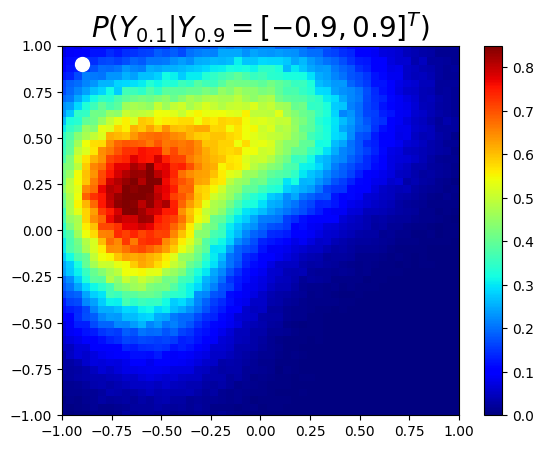

In [7]:
plt.figure(dpi=100)
plt.hist2d(samples[:, 0], samples[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1, 1])
plt.ylim([-1, 1])

# plt.axis("off")
plt.title("$P(Y_{0.1}| Y_{0.9}= [-0.9, 0.9]^T)$", fontsize=20)
plt.plot([-0.9], [0.9], "wo", markersize=10)
plt.clim([0, 0.85])
plt.colorbar()

#### Case 2

In [5]:
T = 0.7
t0 = 0.2
yt = np.array([0.7, 0.3]).reshape([1, -1])
samples = sampler(int(1e6), yt, T, t0)

sio.savemat(
    "./outputs/exact2.mat",
    {
        "samples": samples,
    }
)

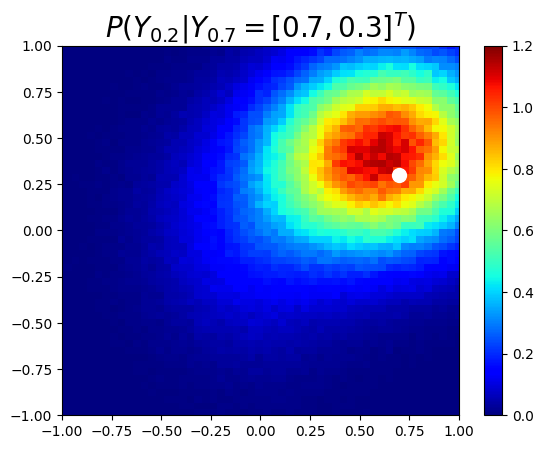

In [6]:
plt.figure(dpi=100)
plt.hist2d(samples[:, 0], samples[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1, 1])
plt.ylim([-1, 1])

# plt.axis("off")
plt.title("$P(Y_{0.2}| Y_{0.7}= [0.7, 0.3]^T)$", fontsize=20)
plt.plot([0.7], [0.3], "wo", markersize=10)
plt.clim([0, 1.2])
plt.colorbar()

#### Case 4

In [7]:
T = 0.3
t0 = 0
yt = np.array([0.3, -0.4]).reshape([1, -1])
samples = sampler(int(1e6), yt, T, t0)

sio.savemat(
    "./outputs/exact4.mat",
    {
        "samples": samples,
    }
)

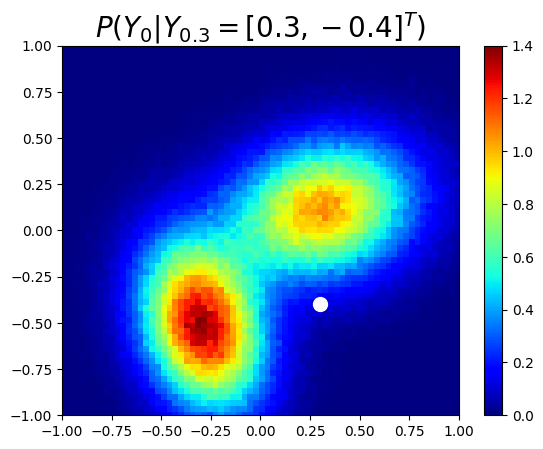

In [8]:
plt.figure(dpi=100)
plt.hist2d(samples[:, 0], samples[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1, 1])
plt.ylim([-1, 1])

# plt.axis("off")
plt.title("$P(Y_0|Y_{0.3} = [0.3, -0.4]^T)$", fontsize=20)
plt.plot([0.3], [-0.4], "wo", markersize=10)
plt.clim([0, 1.4])
plt.colorbar()

#### Case 5

In [9]:
T = 0.8
t0 = 0.3
yt = np.array([-0.5, -0.3]).reshape([1, -1])
samples = sampler(int(1e6), yt, T, t0)

sio.savemat(
    "./outputs/exact5.mat",
    {
        "samples": samples,
    }
)

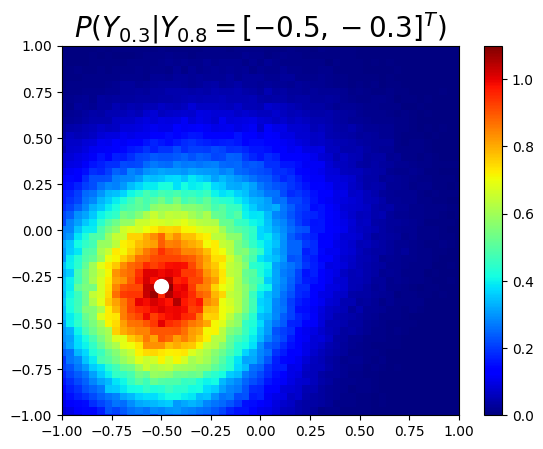

In [10]:
plt.figure(dpi=100)
plt.hist2d(samples[:, 0], samples[:, 1], bins=(100, 100), density=True, cmap=colormaps["jet"])
plt.xlim([-1, 1])
plt.ylim([-1, 1])

# plt.axis("off")
plt.title("$P(Y_{0.3}|Y_{0.8} = [-0.5, -0.3]^T)$", fontsize=20)
plt.plot([-0.5], [-0.3], "wo", markersize=10)
plt.clim([0, 1.1])
plt.colorbar()